# Лабораторная работа №6
## Очистка и трансформация данных. pandas

**Выполнил:** Брискиндов Олег Романович, группа **P3124**

**Ссылка на Colab:** [Открыть в Google Colab](https://colab.research.google.com/)

> _Ссылку на блокнот в Colab вставь здесь после загрузки_

## Введение

### Цель работы
Освоить методы очистки и трансформации данных с помощью библиотеки `pandas` на примере набора Titanic из Kaggle.

### Описание набора данных
Используется набор данных Titanic ([Kaggle competition](https://www.kaggle.com/c/titanic/data)).

| Поле | Значение |
| --- | --- |
| PassengerId | Идентификатор пассажира |
| Survived | Выжил ли (0 — нет, 1 — да) |
| Pclass | Класс билета (1, 2, 3) |
| Name | Имя |
| Sex | Пол |
| Age | Возраст |
| SibSp | Кол-во братьев/сестёр/супругов на борту |
| Parch | Кол-во родителей/детей на борту |
| Ticket | Номер билета |
| Fare | Стоимость билета |
| Cabin | Номер каюты |
| Embarked | Порт посадки (C, Q, S) |

### Подготовка окружения

Подключаем нужные библиотеки и задаём общие параметры визуализации.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 12
RANDOM_STATE = 42

## 1. Первичный анализ данных

Загружаем CSV, смотрим первые строки, типы и пропуски, считаем сводные статистики и строим гистограммы числовых признаков.

In [2]:
# Если запуск в Colab — загрузить train.csv через панель Files,
# либо смонтировать Google Drive и подставить нужный путь.
DATA_PATH = 'train.csv'
df = pd.read_csv(DATA_PATH)
print('Размер датафрейма:', df.shape)
df.head(10)

Размер датафрейма: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [3]:
# Типы данных по столбцам
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [4]:
# Количество пропусков по каждому столбцу
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (df.isna().mean() * 100).round(2)
missing_df = pd.DataFrame({'missing': missing, '%': missing_pct})
missing_df

,missing,%
Age,177,19.87
Cabin,687,77.10
Embarked,2,0.22
Fare,0,0.00
Name,0,0.00
Parch,0,0.00
PassengerId,0,0.00
Pclass,0,0.00
Sex,0,0.00
SibSp,0,0.00


In [5]:
# Сводные статистики числовых признаков
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


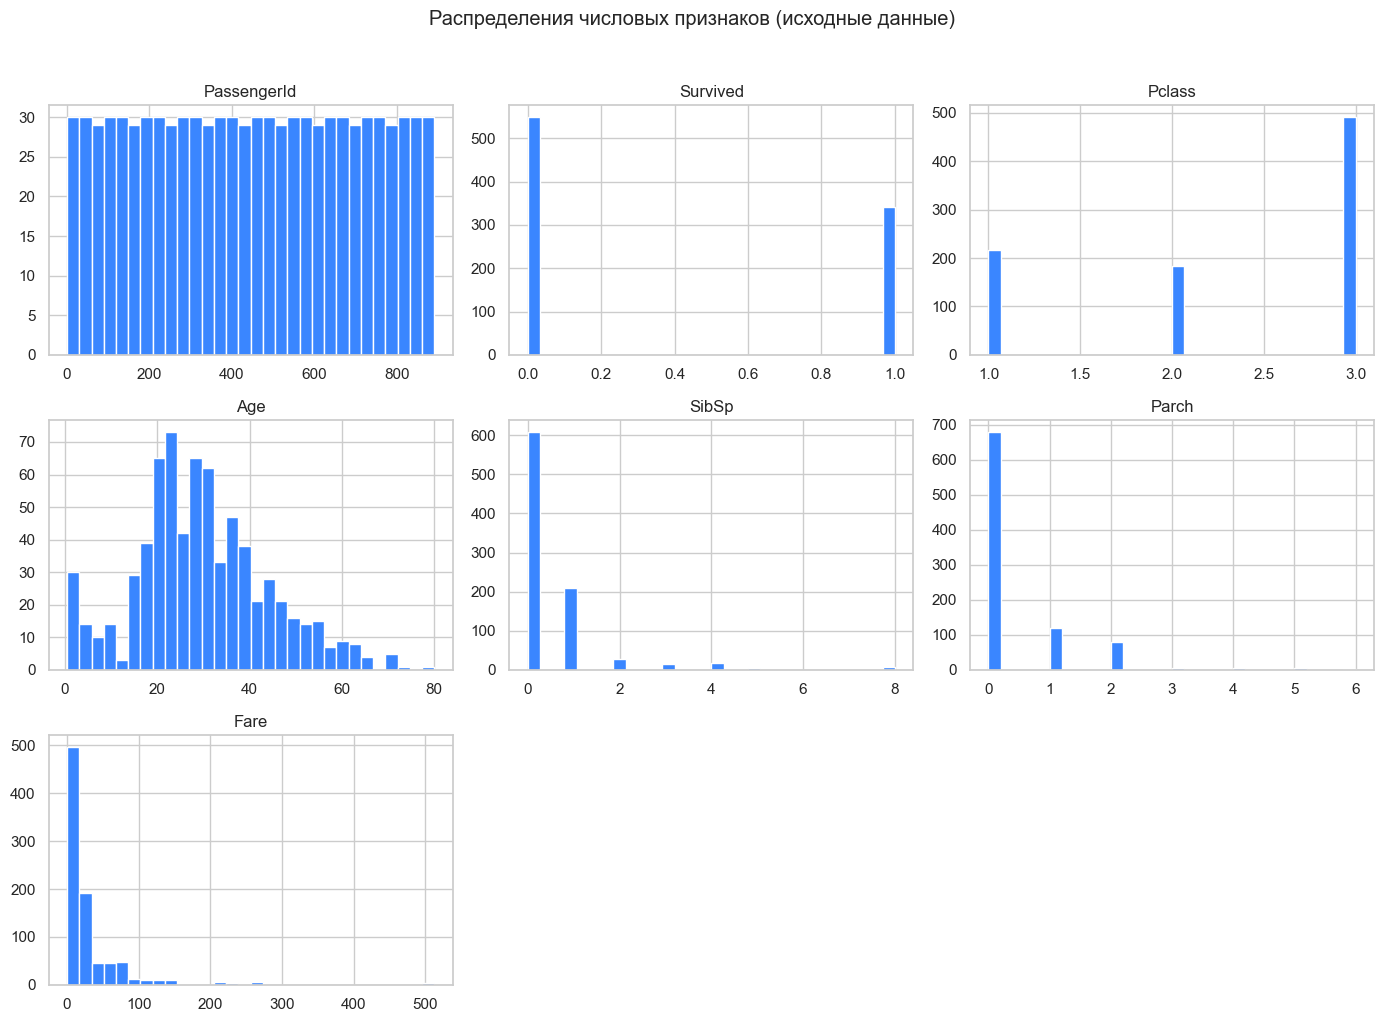

In [6]:
# Гистограммы числовых признаков
numeric_cols = df.select_dtypes(include='number').columns.tolist()
df[numeric_cols].hist(bins=30, figsize=(14, 10), color='#3a86ff', edgecolor='white')
plt.suptitle('Распределения числовых признаков (исходные данные)', y=1.02)
plt.tight_layout()
plt.show()

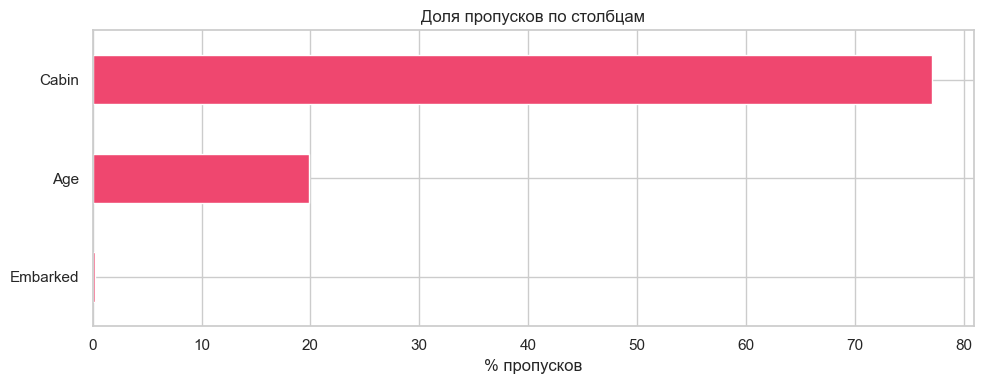

In [7]:
# Визуализация пропусков
fig, ax = plt.subplots(figsize=(10, 4))
missing_pct[missing_pct > 0].sort_values().plot(kind='barh', ax=ax, color='#ef476f')
ax.set_xlabel('% пропусков')
ax.set_title('Доля пропусков по столбцам')
plt.tight_layout()
plt.show()

**Особенности первичного анализа.** В данных 891 пассажир и 12 столбцов. Есть пропуски в `Age` (~20%), `Cabin` (~77%) и `Embarked` (2 строки). Числовые признаки `Age`, `Fare`, `SibSp`, `Parch` имеют разнородные масштабы — у `Fare` тяжёлый правый хвост и подозрение на выбросы.

## 2. Обработка пропусков

Заполняем `Age` медианой, `Embarked` — модой, из `Cabin` извлекаем первую букву (палубу) и заполняем отсутствующие значения значением `'U'` (unknown), а сам исходный столбец удаляем.

In [8]:
cols_with_na = df.columns[df.isna().any()].tolist()
print('Столбцы с пропусками:', cols_with_na)

Столбцы с пропусками: ['Age', 'Cabin', 'Embarked']


In [9]:
# --- Age ---
age_mean = df['Age'].mean()
age_median = df['Age'].median()
print(f'Age: mean={age_mean:.2f}, median={age_median:.2f}')
df['Age'] = df['Age'].fillna(age_median)
print('Пропусков в Age после заполнения:', df['Age'].isna().sum())

Age: mean=29.70, median=28.00
Пропусков в Age после заполнения: 0


In [10]:
# Новый признак Age_group по заполненному Age
age_bins = [0, 12, 18, 35, 60, np.inf]
age_labels = ['Child', 'Teen', 'Young', 'Adult', 'Senior']
df['Age_group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=True)
df['Age_group'].value_counts()

Age_group
Young     535
Adult     195
Teen       70
Child      69
Senior     22
Name: count, dtype: int64

In [11]:
# --- Embarked ---
embarked_mode = df['Embarked'].mode()[0]
print('Мода Embarked:', embarked_mode)
df['Embarked'] = df['Embarked'].fillna(embarked_mode)
print('Пропусков в Embarked:', df['Embarked'].isna().sum())

Мода Embarked: S
Пропусков в Embarked: 0


In [12]:
# --- Cabin ---
# Слишком много пропусков (~77%), поэтому удаляем сам Cabin,
# но извлекаем из него информативный признак Deck (первая буква).
df['Deck'] = df['Cabin'].astype('string').str[0].fillna('U')
df = df.drop(columns=['Cabin'])
df['Deck'].value_counts()

Deck
U    687
C     59
B     47
D     33
E     32
A     15
F     13
G      4
T      1
Name: count, dtype: Int64

In [13]:
# Контроль: пропусков больше быть не должно
df.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Age_group      0
Deck           0
dtype: int64

## 3. Работа с типами данных

Преобразуем `Pclass` в строковые коды (1→F, 2→S, 3→T) — он перестаёт восприниматься как число. Из `Name` извлекаем титул, кодируем `Sex` числом, считаем размер семьи и признак одиночества.

In [14]:
# Pclass в строковую категорию
pclass_map = {1: 'F', 2: 'S', 3: 'T'}
df['Pclass'] = df['Pclass'].map(pclass_map).astype('category')
df['Pclass'].value_counts()

Pclass
T    491
F    216
S    184
Name: count, dtype: int64

In [15]:
# Title из Name (всё, что между запятой и точкой: 'Mr', 'Mrs', 'Miss'...)
df['Title'] = df['Name'].str.extract(r',\s*([^.]+)\.', expand=False).str.strip()
rare_titles = {
    'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs',
    'Lady': 'Royal', 'Countess': 'Royal', 'Sir': 'Royal',
    'Don': 'Royal', 'Jonkheer': 'Royal', 'the Countess': 'Royal',
    'Capt': 'Officer', 'Col': 'Officer', 'Major': 'Officer',
    'Dr': 'Officer', 'Rev': 'Officer',
}
df['Title'] = df['Title'].replace(rare_titles)
df['Title'].value_counts()

Title
Mr         517
Miss       185
Mrs        126
Master      40
Officer     18
Royal        5
Name: count, dtype: int64

In [16]:
# Sex в число: female=1, male=0
df['Sex'] = df['Sex'].map({'female': 1, 'male': 0}).astype('int8')
df['Sex'].value_counts()

Sex
0    577
1    314
Name: count, dtype: int64

In [17]:
# FamilySize и IsAlone
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype('int8')
df[['FamilySize', 'IsAlone']].describe()

,FamilySize,IsAlone
count,891.000000,891.000000
mean,1.904602,0.602694
std,1.613459,0.489615
min,1.000000,0.000000
25%,1.000000,0.000000
50%,1.000000,1.000000
75%,2.000000,1.000000
max,11.000000,1.000000


In [18]:
df.dtypes

PassengerId             int64
Survived                int64
Pclass               category
Name                   object
Sex                      int8
Age                   float64
SibSp                   int64
Parch                   int64
Ticket                 object
Fare                  float64
Embarked               object
Age_group            category
Deck           string[python]
Title                  object
FamilySize              int64
IsAlone                  int8
dtype: object

## 4. Удаление выбросов

Смотрим распределение `Fare` и `Age`, выявляем выбросы по правилу межквартильного размаха (IQR), для `Fare` применяем винзоризацию (обрезка по 5-му и 95-му перцентилям), а экстремальные значения `Age` ограничиваем 95-м перцентилем.

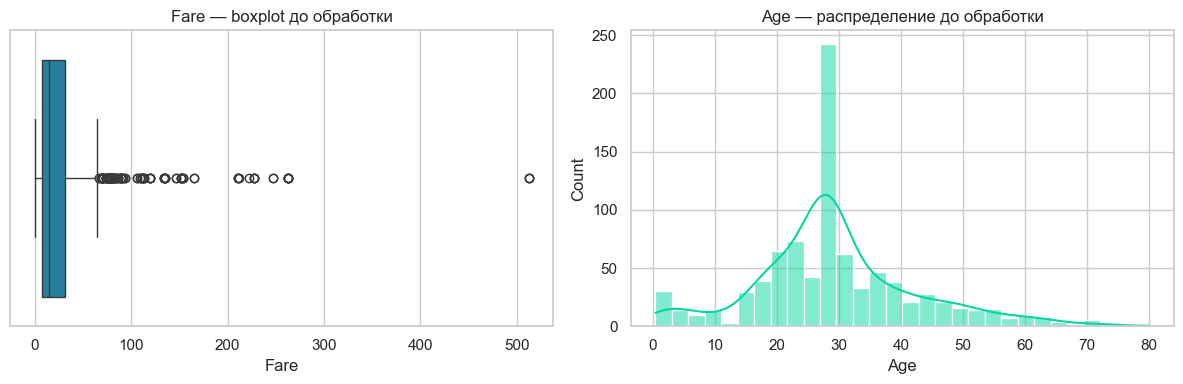

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df['Fare'], ax=axes[0], color='#118ab2')
axes[0].set_title('Fare — boxplot до обработки')
sns.histplot(df['Age'], bins=30, kde=True, ax=axes[1], color='#06d6a0')
axes[1].set_title('Age — распределение до обработки')
plt.tight_layout()
plt.show()

In [20]:
# IQR для Fare
q1, q3 = df['Fare'].quantile([0.25, 0.75])
iqr = q3 - q1
low_fare = q1 - 1.5 * iqr
high_fare = q3 + 1.5 * iqr
fare_outliers = df[(df['Fare'] < low_fare) | (df['Fare'] > high_fare)]
print(f'IQR-границы Fare: [{low_fare:.2f}, {high_fare:.2f}]')
print('Кол-во выбросов Fare:', len(fare_outliers))

IQR-границы Fare: [-26.72, 65.63]
Кол-во выбросов Fare: 116


In [21]:
# Винзоризация Fare по 5-му и 95-му перцентилям
fare_low, fare_high = df['Fare'].quantile([0.05, 0.95])
df['Fare'] = df['Fare'].clip(lower=fare_low, upper=fare_high)
print(f'Перцентили 5%/95%: {fare_low:.2f} / {fare_high:.2f}')

Перцентили 5%/95%: 7.22 / 112.08


In [22]:
# Экстремальные значения Age — отсечь по 95-му перцентилю
age_p95 = df['Age'].quantile(0.95)
n_clipped = (df['Age'] > age_p95).sum()
df['Age'] = df['Age'].clip(upper=age_p95)
print(f'Возраст ограничен сверху значением {age_p95:.2f}, '
      f'отсечено: {n_clipped} наблюдений')

Возраст ограничен сверху значением 54.00, отсечено: 42 наблюдений


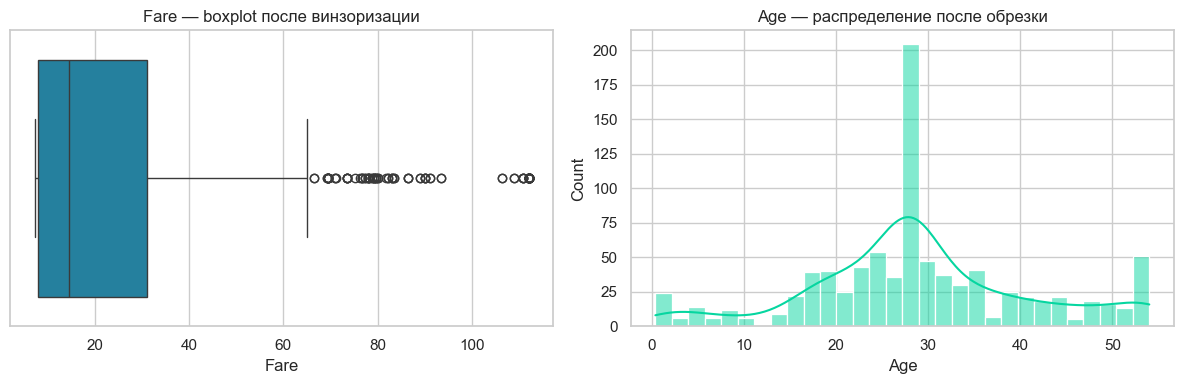

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df['Fare'], ax=axes[0], color='#118ab2')
axes[0].set_title('Fare — boxplot после винзоризации')
sns.histplot(df['Age'], bins=30, kde=True, ax=axes[1], color='#06d6a0')
axes[1].set_title('Age — распределение после обрезки')
plt.tight_layout()
plt.show()

## 5. Агрегация данных

Считаем долю выживших по классам и полу, медианный возраст по портам, строим сводную таблицу выживаемости и сохраняем очищенный набор в CSV.

In [24]:
# Средняя выживаемость по классам
df.groupby('Pclass', observed=True)['Survived'].mean().round(3)

Pclass
F    0.630
S    0.473
T    0.242
Name: Survived, dtype: float64

In [25]:
# Группировка по Pclass и Sex
df.groupby(['Pclass', 'Sex'], observed=True).agg(
    survived_rate=('Survived', 'mean'),
    passengers=('Survived', 'size'),
    median_fare=('Fare', 'median'),
).round(3)

survived_rate  passengers  median_fare
Pclass Sex                                        
F      0            0.369         122       41.262
       1            0.968          94       82.665
S      0            0.157         108       13.000
       1            0.921          76       22.000
T      0            0.135         347        7.925
       1            0.500         144       12.475

In [26]:
# Медианный возраст по портам посадки
df.groupby('Embarked')['Age'].median()

Embarked
C    28.0
Q    28.0
S    28.0
Name: Age, dtype: float64

In [27]:
# Сводная таблица выживаемости по новым признакам
pivot = df.pivot_table(
    index='Title',
    columns='IsAlone',
    values='Survived',
    aggfunc='mean',
).round(3)
pivot

IsAlone,0,1
Title,,
Master,0.575,NaN
Miss,0.634,0.757
Mr,0.167,0.154
Mrs,0.771,0.905
Officer,0.200,0.308
Royal,1.000,0.333


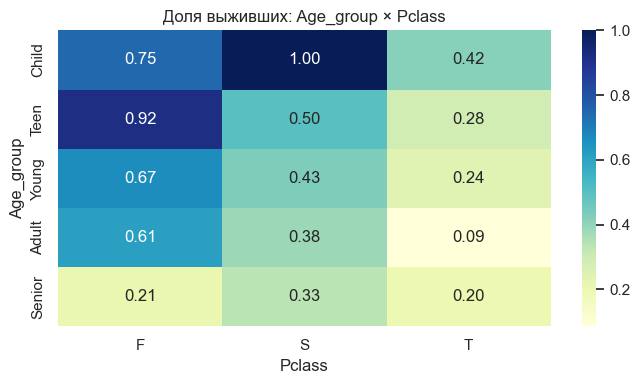

In [28]:
# Тепловая карта — выживаемость по Age_group и Pclass
heat = df.pivot_table(
    index='Age_group', columns='Pclass', values='Survived',
    aggfunc='mean', observed=True,
).round(3)
fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(heat, annot=True, fmt='.2f', cmap='YlGnBu', ax=ax)
ax.set_title('Доля выживших: Age_group × Pclass')
plt.tight_layout()
plt.show()

In [29]:
# Сохраняем очищенный датасет
OUT_PATH = 'titanic_cleaned.csv'
df.to_csv(OUT_PATH, index=False)
print('Очищенные данные сохранены:', OUT_PATH)
print('Размер:', df.shape)

Очищенные данные сохранены: titanic_cleaned.csv
Размер: (891, 16)


## 6. Метрики качества очистки данных

Считаем процент заполненных пропусков, число уникальных значений в категориальных признаках, распределения после трансформации и корреляции между новыми и целевым признаками.

In [30]:
# Сравнение пропусков до/после
raw = pd.read_csv(DATA_PATH)
before = raw.isna().sum()
# В очищенном датафрейме столбца Cabin уже нет — учтём это
after = df.reindex(columns=raw.columns).isna().sum()
filled_pct = ((before - after) / before.replace(0, np.nan) * 100).fillna(0)
quality = pd.DataFrame({
    'before': before,
    'after': after,
    'filled_%': filled_pct.round(2),
})
quality[quality['before'] > 0]

,before,after,filled_%
Age,177,0,100.00
Cabin,687,891,-29.69
Embarked,2,0,100.00


In [31]:
# Уникальные значения в категориальных признаках
cat_cols = ['Pclass', 'Sex', 'Embarked', 'Age_group', 'Title', 'Deck', 'IsAlone']
pd.Series({c: df[c].nunique() for c in cat_cols}, name='unique_values')

Pclass       3
Sex          2
Embarked     3
Age_group    5
Title        6
Deck         9
IsAlone      2
Name: unique_values, dtype: int64

In [32]:
# Распределения значений ключевых трансформированных признаков
for col in ['Age_group', 'Title', 'Deck', 'IsAlone']:
    print(f'--- {col} ---')
    print(df[col].value_counts(normalize=True).round(3))
    print()

--- Age_group ---
Age_group
Young     0.600
Adult     0.219
Teen      0.079
Child     0.077
Senior    0.025
Name: proportion, dtype: float64

--- Title ---
Title
Mr         0.580
Miss       0.208
Mrs        0.141
Master     0.045
Officer    0.020
Royal      0.006
Name: proportion, dtype: float64

--- Deck ---
Deck
U    0.771
C    0.066
B    0.053
D    0.037
E    0.036
A    0.017
F    0.015
G    0.004
T    0.001
Name: proportion, dtype: Float64

--- IsAlone ---
IsAlone
1    0.603
0    0.397
Name: proportion, dtype: float64



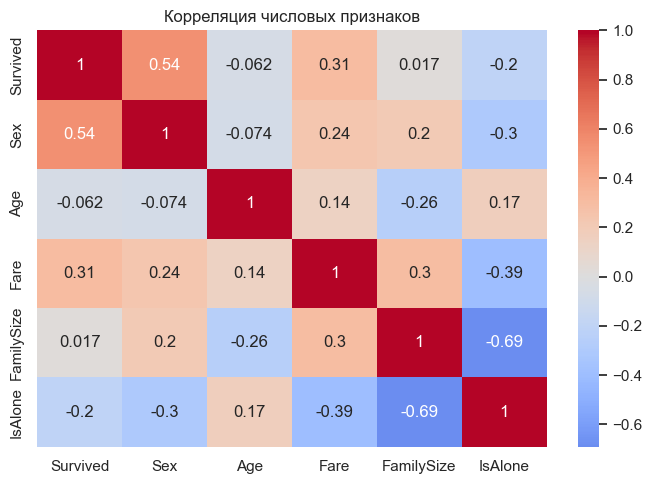

,Survived,Sex,Age,Fare,FamilySize,IsAlone
Survived,1.000,0.543,-0.062,0.313,0.017,-0.203
Sex,0.543,1.000,-0.074,0.237,0.201,-0.304
Age,-0.062,-0.074,1.000,0.135,-0.255,0.174
Fare,0.313,0.237,0.135,1.000,0.304,-0.394
FamilySize,0.017,0.201,-0.255,0.304,1.000,-0.691
IsAlone,-0.203,-0.304,0.174,-0.394,-0.691,1.000


In [33]:
# Корреляция новых и числовых признаков с целевой переменной
num_for_corr = df[['Survived', 'Sex', 'Age', 'Fare', 'FamilySize', 'IsAlone']]
corr = num_for_corr.corr(numeric_only=True).round(3)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, ax=ax)
ax.set_title('Корреляция числовых признаков')
plt.tight_layout()
plt.show()
corr

## Заключение

### Результаты работы
- Загружен и проанализирован набор Titanic (891 строка, 12 столбцов).
- Заполнены пропуски: `Age` — медианой, `Embarked` — модой; из `Cabin` извлечён признак `Deck`, сам `Cabin` удалён.
- Выполнены преобразования типов: `Pclass` → строковая категория (F/S/T), `Sex` → 0/1, добавлены `Title`, `Age_group`, `FamilySize`, `IsAlone`.
- Обработаны выбросы `Fare` (винзоризация по 5/95 перцентилям) и `Age` (обрезка сверху по 95-му перцентилю).
- Выполнена агрегация: посчитаны коэффициенты выживаемости по классу, полу, возрастной группе и порту посадки; построена тепловая карта.
- Сохранён очищенный датасет `titanic_cleaned.csv`.

### Выводы
- Самые сильные корреляции с `Survived` — у `Sex` (положительная: женщины выживали чаще) и `Fare` (положительная: дорогой билет = выше класс = больше шансов).
- Класс билета — ключевой фактор: в 1-м классе выжили ≈63% пассажиров, в 3-м — лишь ≈24%.
- Признак `IsAlone` показывает заметный эффект — одиночные пассажиры выживали реже, чем те, кто путешествовал с семьёй небольшого размера.
- `Cabin` нельзя использовать «в лоб» из-за 77% пропусков, но первая буква (палуба) даёт пригодный к анализу категориальный признак.
- Винзоризация `Fare` существенно уменьшила влияние выбросов и сделала распределение пригодным для использования в моделях, чувствительных к шкалам.